In [1]:
from TestEnv import HydroElectric_Test
import os
import numpy as np
import pandas as pd
from tabular_Qagent import *
from collections import deque

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
current_dir = os.getcwd()
file_path = os.path.normpath(os.path.join(current_dir, '..', 'data\\train.xlsx'))
env = HydroElectric_Test(file_path)

Experiment gather data using random agent


In [3]:
n_episodes = 10

history = {
    'step': [],
    'price': [],
    'current_volume': [],
    'next_volume': [],
    'action': [],
    'raw_reward': [],
}
i = 0

action_list = [-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]

for episode in range(n_episodes):
    env = HydroElectric_Test(file_path)
    observation = env.observation()
    done = False   
    
    while not done:
        i += 1
        action_idx = np.random.randint(0, len(action_list))
        action = action_list[action_idx]

        current_volume = observation[0] 
        current_price  = observation[1] 

        next_observation, reward, terminated, truncated, info = env.step(action)

        next_volume = next_observation[0]

        next_volume = next_observation[0]
        done = truncated or terminated

        history['step'].append(i) 
        history['price'].append(current_price)
        history['current_volume'].append(current_volume)
        history['next_volume'].append(next_volume)
        history['action'].append(action)
        history['raw_reward'].append(reward)

        observation = next_observation



The current reward problem

In [5]:
# Convert to DataFrame
# limit prices for a clearer overview
df = pd.DataFrame(history)
df = df[df.price < 200]

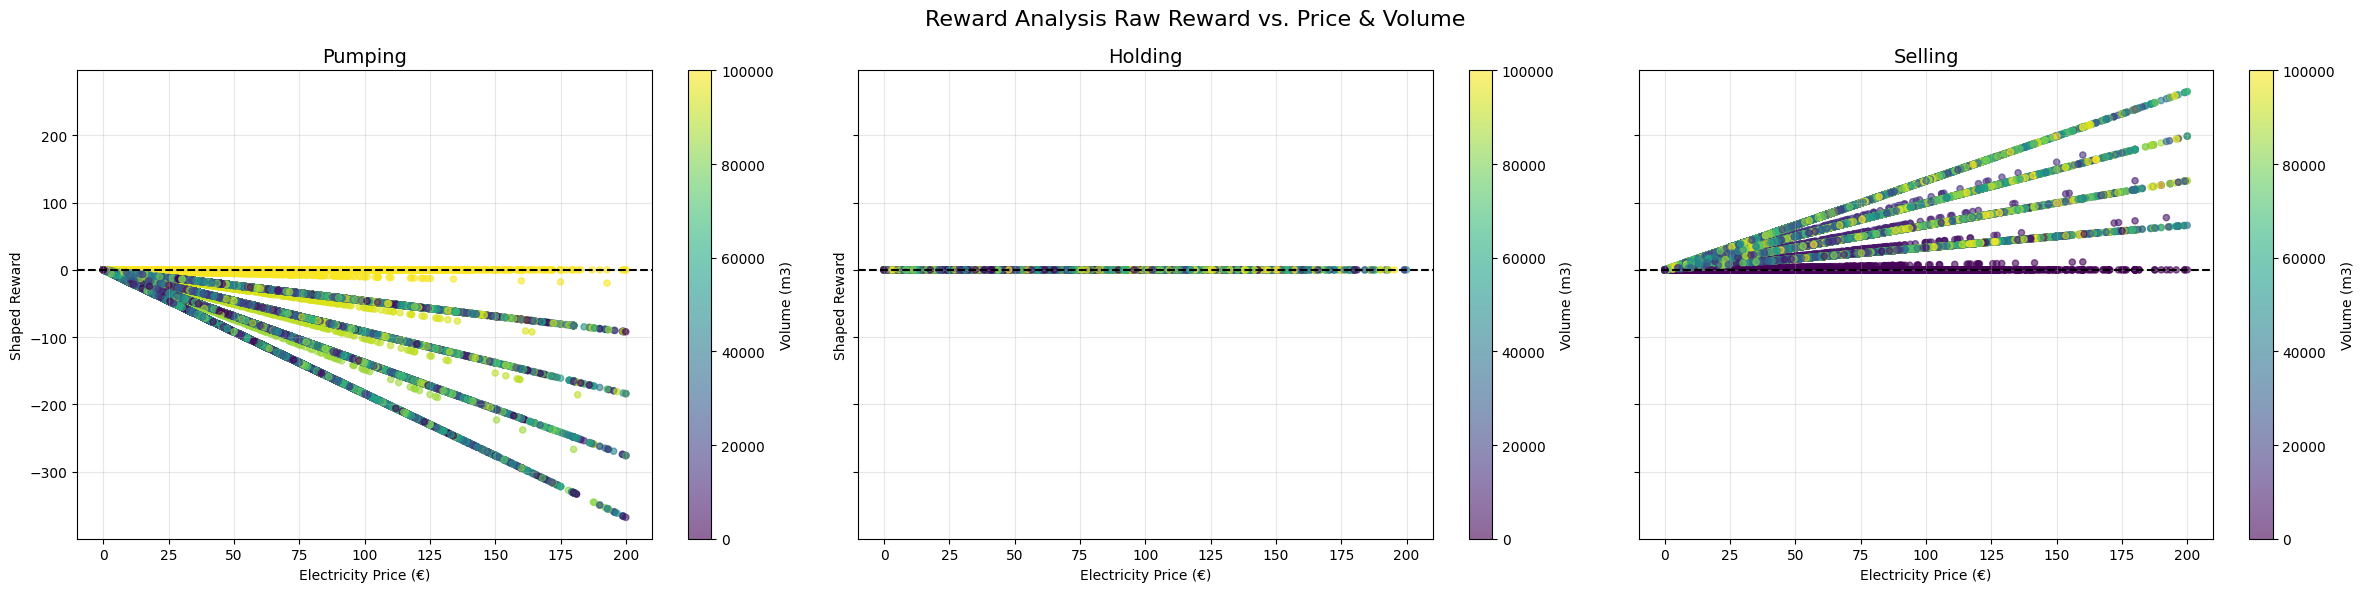

In [6]:
# Raw rewards
df_pump = df[df['action'] > 0].copy()
df_hold = df[df['action'] == 0].copy()
df_sell = df[df['action'] < 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

sc1 = axes[0].scatter(df_pump['price'], df_pump['raw_reward'], 
                      c=df_pump['current_volume'], cmap='viridis', 
                      s=20, alpha=0.6, label='Pump Actions')

axes[0].set_title("Pumping", fontsize=14)
axes[0].set_xlabel("Electricity Price (€)")
axes[0].set_ylabel("Shaped Reward")
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].grid(True, alpha=0.3)

cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label('Volume (m3)')

sc2 = axes[1].scatter(df_hold['price'], df_hold['raw_reward'], 
                      c=df_hold['current_volume'], cmap='viridis', 
                      s=20, alpha=0.6, label='Hold Action')

axes[1].set_title("Holding", fontsize=14)
axes[1].set_xlabel("Electricity Price (€)")
axes[1].set_ylabel("Shaped Reward")
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].grid(True, alpha=0.3)

cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label('Volume (m3)')

sc3 = axes[2].scatter(df_sell['price'], df_sell['raw_reward'], 
                      c=df_sell['current_volume'], cmap='viridis', 
                      s=20, alpha=0.6, label='Sell Actions')

axes[2].set_title("Selling", fontsize=14)
axes[2].set_xlabel("Electricity Price (€)")
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[2].grid(True, alpha=0.3)

cbar3 = plt.colorbar(sc3, ax=axes[2])
cbar3.set_label('Volume (m3)')

plt.suptitle("Reward Analysis Raw Reward vs. Price & Volume", fontsize=16)
plt.tight_layout()
plt.show()

Pumping only has negative rewards. The reward for holding is always 0, and selling is always positive. The reward for pumping when the reservoir is full, holding and selling when the reservoir is empty are all 0. Thus the based on the raw reward the agent cannot distinguish effectively in the direct reward between pumping and holding or selling and holding. Also as pumping is always negative, the agent can only learn that this is good, if the consecutive periods afterwards are all selling and we use a high gamma. Also on the long term, holding when the volume is large should not less favorable then when the volume is low. In the latter, we have a full reservoir full of potential sales. 

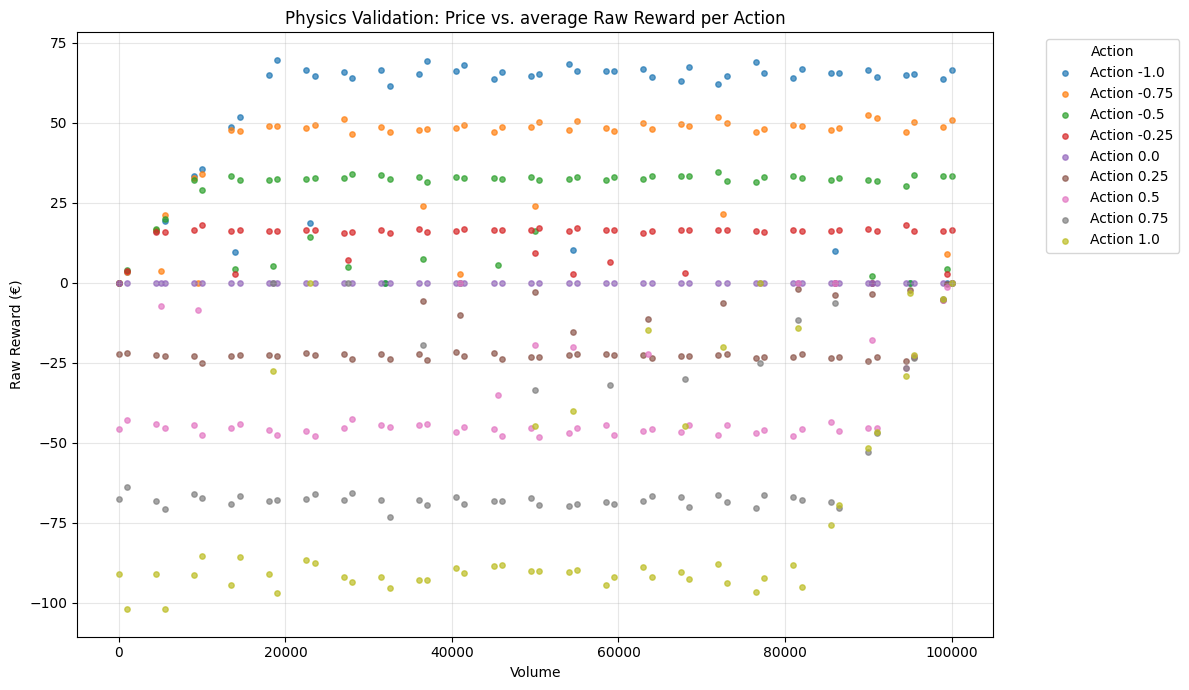

In [7]:
plt.figure(figsize=(12, 7))

for action in sorted(df['action'].unique()):
    df_temp = df[df['action'] == action]
    
    df_group = df_temp.groupby('current_volume')['raw_reward'].mean()
    plt.scatter(df_group.index, df_group.values, label=f'Action {action}', s=15, alpha=0.7)

plt.xlabel('Volume')
plt.ylabel('Raw Reward (€)')
plt.title('Physics Validation: Price vs. average Raw Reward per Action')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Shaped Reward without penalty

In [8]:
def get_shaped_reward(reward, 
                    current_volume, 
                    next_volume, 
                    avg_price):
    
    # Value the potential based on the rolling average of 24 hours
    current_potential = current_volume * env.volume_to_MWh * avg_price * env.flow_efficiency
    next_potential = next_volume * env.volume_to_MWh * avg_price * env.flow_efficiency

    potential_delta = next_potential - current_potential
            
    return reward + potential_delta

    
def get_reward_penalty(action, current_volume, next_volume, max_flow=18_000):
    """
    Penalizes when the actual volume change differs from intended flow.
    Action is in [-1, 1] range, intended_flow = action * max_flow
    """
    volume_delta = next_volume - current_volume
    intended_flow = action * max_flow
    
    penalty = 0
    
    if action > 0:
        if volume_delta < intended_flow:
            flow_pct = volume_delta / intended_flow
            penalty = -25 * (1 - flow_pct)
    
    elif action < 0: 
        if abs(volume_delta) < abs(intended_flow):
            flow_pct = abs(volume_delta) / abs(intended_flow)
            penalty = -25 * (1 - flow_pct)
    
   
    return penalty

constant average price

In [14]:
df.price.std()

np.float64(28.491282561658984)

In [15]:
df['rolling_price'] = df.price.rolling(24).mean().fillna(50)
df['rolling_std'] = df.price.rolling(24).std().fillna(28)
df['price_diff'] = df.price - df.rolling_price
df['z_score'] = df.price_diff / df.rolling_std+1e-5

df['shaped_reward_rolling'] = get_shaped_reward(df.raw_reward, df.current_volume, df.next_volume, df.rolling_price)
df['shaped_reward_constant'] = get_shaped_reward(df.raw_reward, df.current_volume, df.next_volume, df.price.mean())
df['penalty'] = df.apply(lambda row: get_reward_penalty(
    row['action'], row['current_volume'], row['next_volume']), axis=1)

df['shaped_penalty_reward'] = df.shaped_reward_rolling + df.penalty
df['intended_flow'] = df.action*18_000
df['actual_flow'] = df.next_volume - df.current_volume

In [16]:
df

,step,price,current_volume,next_volume,action,raw_reward,rolling_price,rolling_std,price_diff,z_score,shaped_reward_rolling,shaped_reward_constant,penalty,shaped_penalty_reward,intended_flow,actual_flow
0,1,24.31,50000.0,36500.0,-0.75,24.146231,50.000000,28.000000,-25.690000,-0.917490,-25.516934,-25.034005,0.000000,-25.516934,-13500.0,-13500.0
1,2,24.31,36500.0,23000.0,-0.75,24.146231,50.000000,28.000000,-25.690000,-0.917490,-25.516934,-25.034005,0.000000,-25.516934,-13500.0,-13500.0
2,3,21.71,23000.0,14000.0,-0.50,14.375831,50.000000,28.000000,-28.290000,-1.010347,-18.732946,-18.410993,0.000000,-18.732946,-9000.0,-9000.0
3,4,8.42,14000.0,9500.0,-0.25,2.787759,50.000000,28.000000,-41.580000,-1.484990,-13.766629,-13.605653,0.000000,-13.766629,-4500.0,-4500.0
4,5,0.01,9500.0,0.0,-0.75,0.006990,50.000000,28.000000,-49.990000,-1.785347,-34.941163,-34.601324,-7.407407,-42.348571,-13500.0,-9500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263025,263026,40.48,63000.0,49500.0,-0.75,40.207298,27.387083,11.680708,13.092917,1.120911,13.004714,-8.972937,0.000000,13.004714,-13500.0,-13500.0
263026,263027,36.00,49500.0,54000.0,0.25,-16.554388,27.137083,11.415551,8.862917,0.776400,-7.569632,-0.160976,0.000000,-7.569632,4500.0,4500.0
263027,263028,29.00,54000.0,36000.0,-1.00,38.406181,26.928333,11.329892,2.071667,0.182860,2.743614,-27.167467,0.000000,2.743614,-18000.0,-18000.0
263028,263029,24.82,36000.0,49500.0,0.75,-34.239993,26.788333,11.334511,-1.968333,-0.173648,-7.632125,14.940242,0.000000,-7.632125,13500.0,13500.0


In [17]:
df.describe()

,step,price,current_volume,next_volume,action,raw_reward,rolling_price,rolling_std,price_diff,z_score,shaped_reward_rolling,shaped_reward_constant,penalty,shaped_penalty_reward,intended_flow,actual_flow
count,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000,262270.000000
mean,131529.831872,49.513795,50075.559538,50075.180158,-0.000875,-6.257239,49.516281,16.580087,-0.002485,-0.005594,-6.265753,-6.258621,-2.510631,-8.776384,-15.750944,-0.379380
std,75930.855569,28.491283,32118.575097,32119.914429,0.645638,54.415624,21.756581,8.842962,19.151708,1.044905,20.816851,28.767050,7.074372,21.388346,11621.484216,10747.914224
min,1.000000,0.010000,0.000000,0.000000,-1.000000,-367.856901,6.037500,2.044994,-104.112500,-3.341465,-266.267402,-302.283253,-25.000000,-266.267402,-18000.000000,-18000.000000
25%,65794.250000,29.840000,22500.000000,22500.000000,-0.500000,-33.568621,32.234167,10.123231,-10.910833,-0.787848,-12.693468,-14.636592,0.000000,-20.529541,-9000.000000,-9000.000000
50%,131515.500000,43.000000,50500.000000,50500.000000,0.000000,0.000000,42.728333,14.351603,0.881250,0.069556,-0.319454,0.000000,0.000000,-4.357667,0.000000,0.000000
75%,197308.750000,64.950000,77500.000000,77500.000000,0.500000,23.997241,65.832083,20.852232,10.282083,0.712882,2.000575,3.779826,0.000000,1.612351,9000.000000,9000.000000
max,263030.000000,199.990000,100000.000000,100000.000000,1.000000,264.856968,144.277083,66.718748,136.375417,4.419541,180.608928,199.283321,0.000000,180.608928,18000.000000,18000.000000


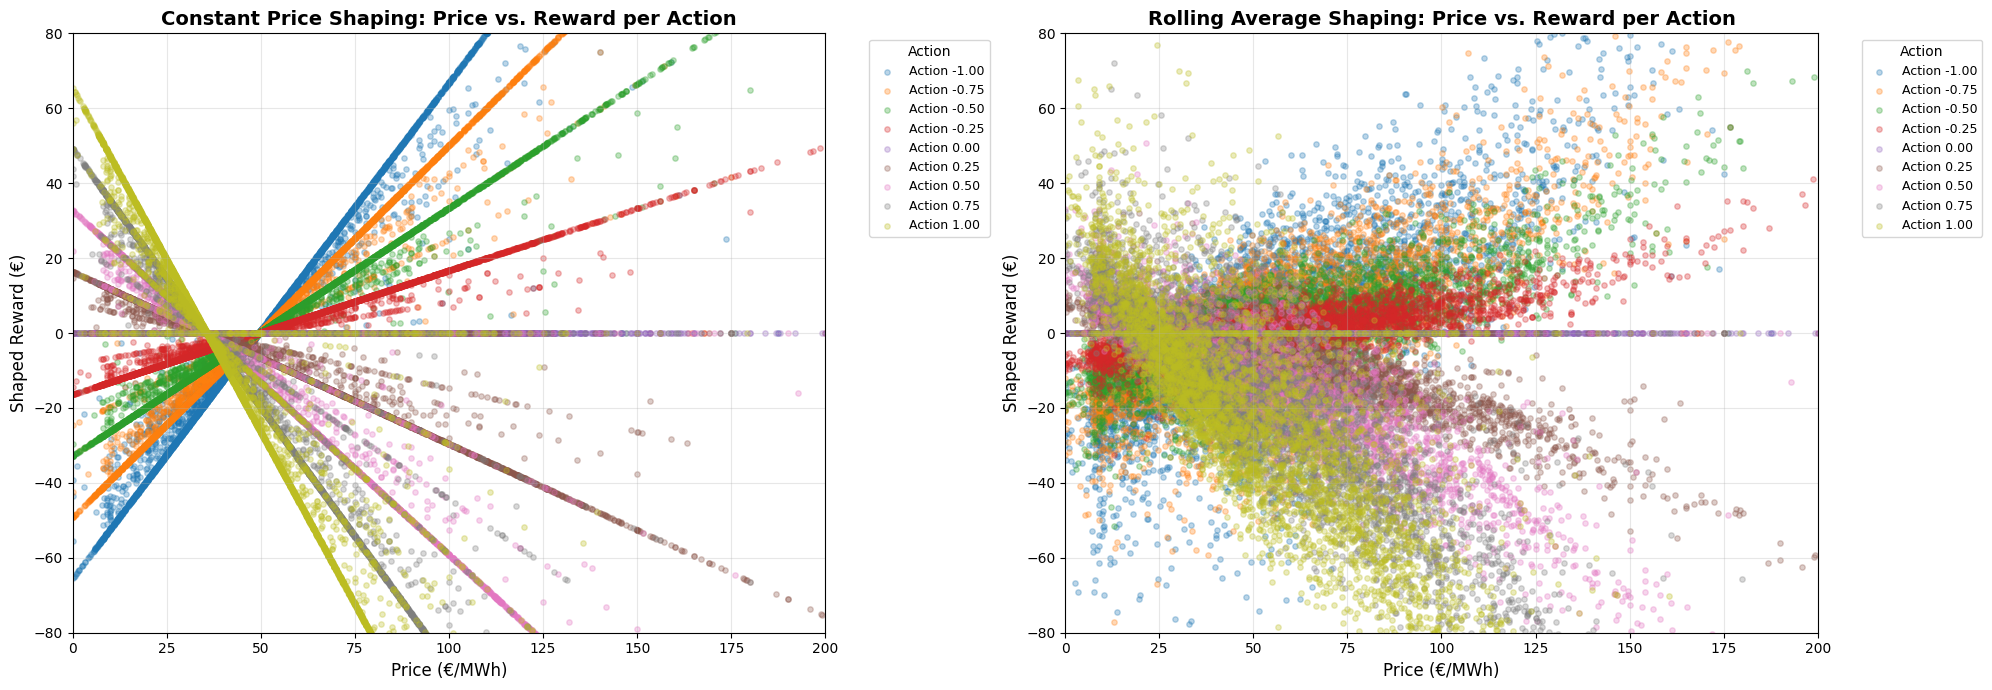

In [18]:
# Sample data
df_small = df.sample(100_000)

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Left plot: shaped_reward_constant
for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    df_group = df_temp.groupby('price')['shaped_reward_constant'].mean()
    ax1.scatter(df_group.index, df_group.values, label=f'Action {action:.2f}', s=15, alpha=0.3)

ax1.set_xlabel('Price (€/MWh)', fontsize=12)
ax1.set_ylabel('Shaped Reward (€)', fontsize=12)
ax1.set_title('Constant Price Shaping: Price vs. Reward per Action', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action', fontsize=9)
ax1.set_xlim(0, 200)
ax1.set_ylim(-80, 80)
ax1.grid(True, alpha=0.3)

for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    df_group = df_temp.groupby('price')['shaped_reward_rolling'].mean()
    ax2.scatter(df_group.index, df_group.values, label=f'Action {action:.2f}', s=15, alpha=0.3)

ax2.set_xlabel('Price (€/MWh)', fontsize=12)
ax2.set_ylabel('Shaped Reward (€)', fontsize=12)
ax2.set_title('Rolling Average Shaping: Price vs. Reward per Action', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action', fontsize=9)
ax2.set_xlim(0, 200)
ax2.set_ylim(-80, 80)
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()



For the constant price, we see that selling gets a positve reward for prices larger than the fixed average of 50. The reward shaping based on the potential volume ensures that for low prices, a positive and the highest reward is given for pump actions. Between these prices, there is a gap due to the inefficiencies of pumping and selling. . Thus showing that the shaped reward acts as expected. When the rolling average is taken to value the potential energy in the dam, the distinction is less clear due to the dynamics of the changing rolling mean

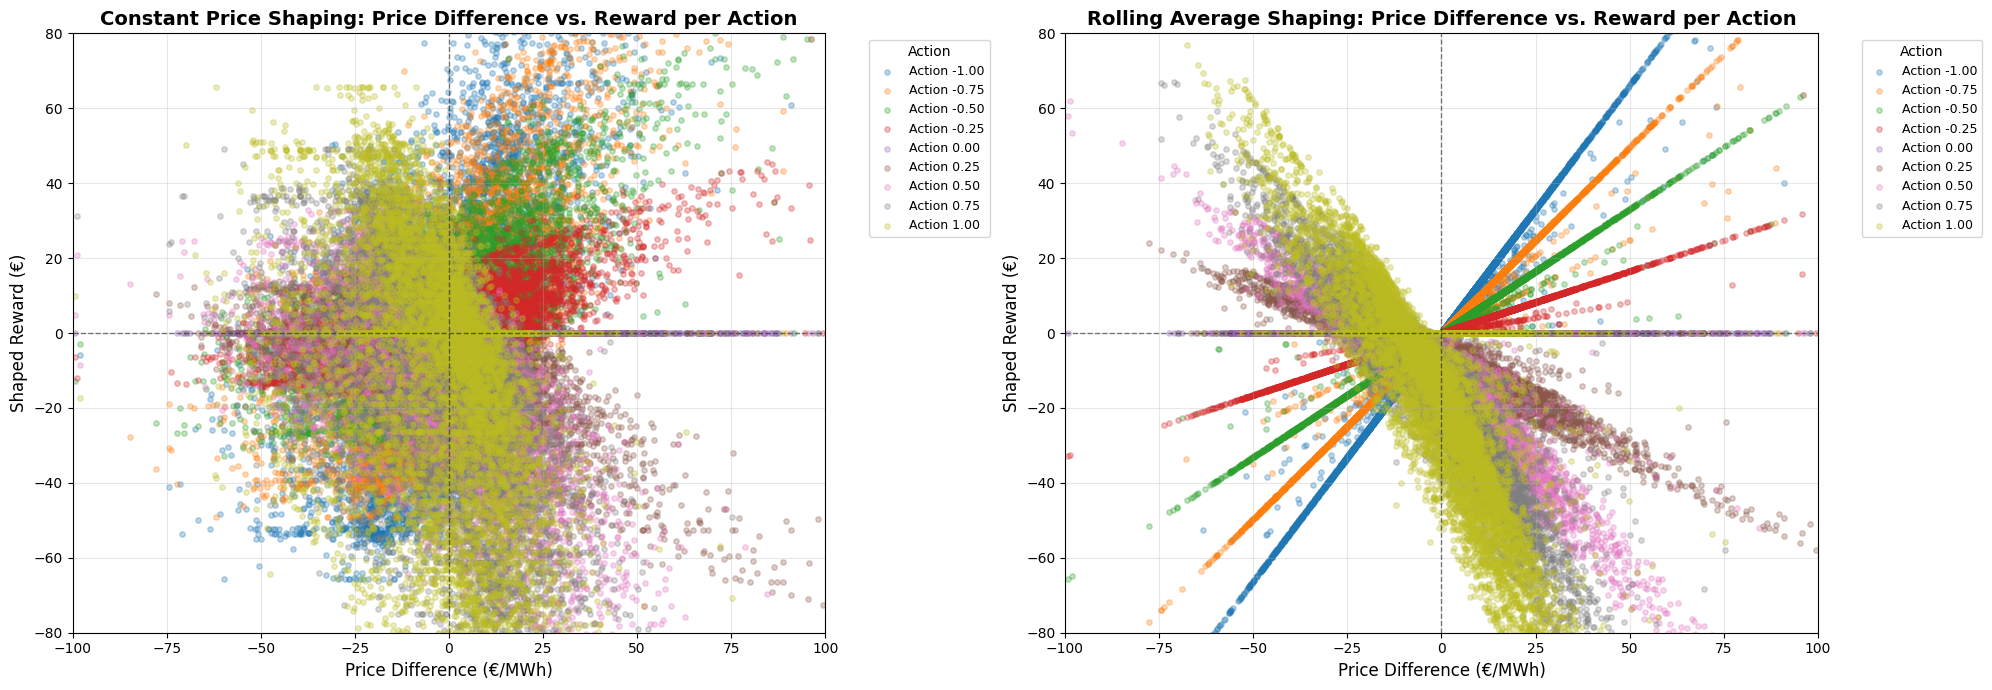

In [19]:
df_small = df.sample(100_000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    df_group = df_temp.groupby('price_diff')['shaped_reward_constant'].mean()
    ax1.scatter(df_group.index, df_group.values, label=f'Action {action:.2f}', s=15, alpha=0.3)

ax1.set_xlabel('Price Difference (€/MWh)', fontsize=12)
ax1.set_ylabel('Shaped Reward (€)', fontsize=12)
ax1.set_title('Constant Price Shaping: Price Difference vs. Reward per Action', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action', fontsize=9)
ax1.set_xlim(-100, 100)
ax1.set_ylim(-80, 80)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    df_group = df_temp.groupby('price_diff')['shaped_reward_rolling'].mean()
    ax2.scatter(df_group.index, df_group.values, label=f'Action {action:.2f}', s=15, alpha=0.3)

ax2.set_xlabel('Price Difference (€/MWh)', fontsize=12)
ax2.set_ylabel('Shaped Reward (€)', fontsize=12)
ax2.set_title('Rolling Average Shaping: Price Difference vs. Reward per Action', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action', fontsize=9)
ax2.set_xlim(-100, 100)
ax2.set_ylim(-80, 80)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()


However, when looking at the difference between the current price and the corresponding rolling average, the similar pattern can be seen/

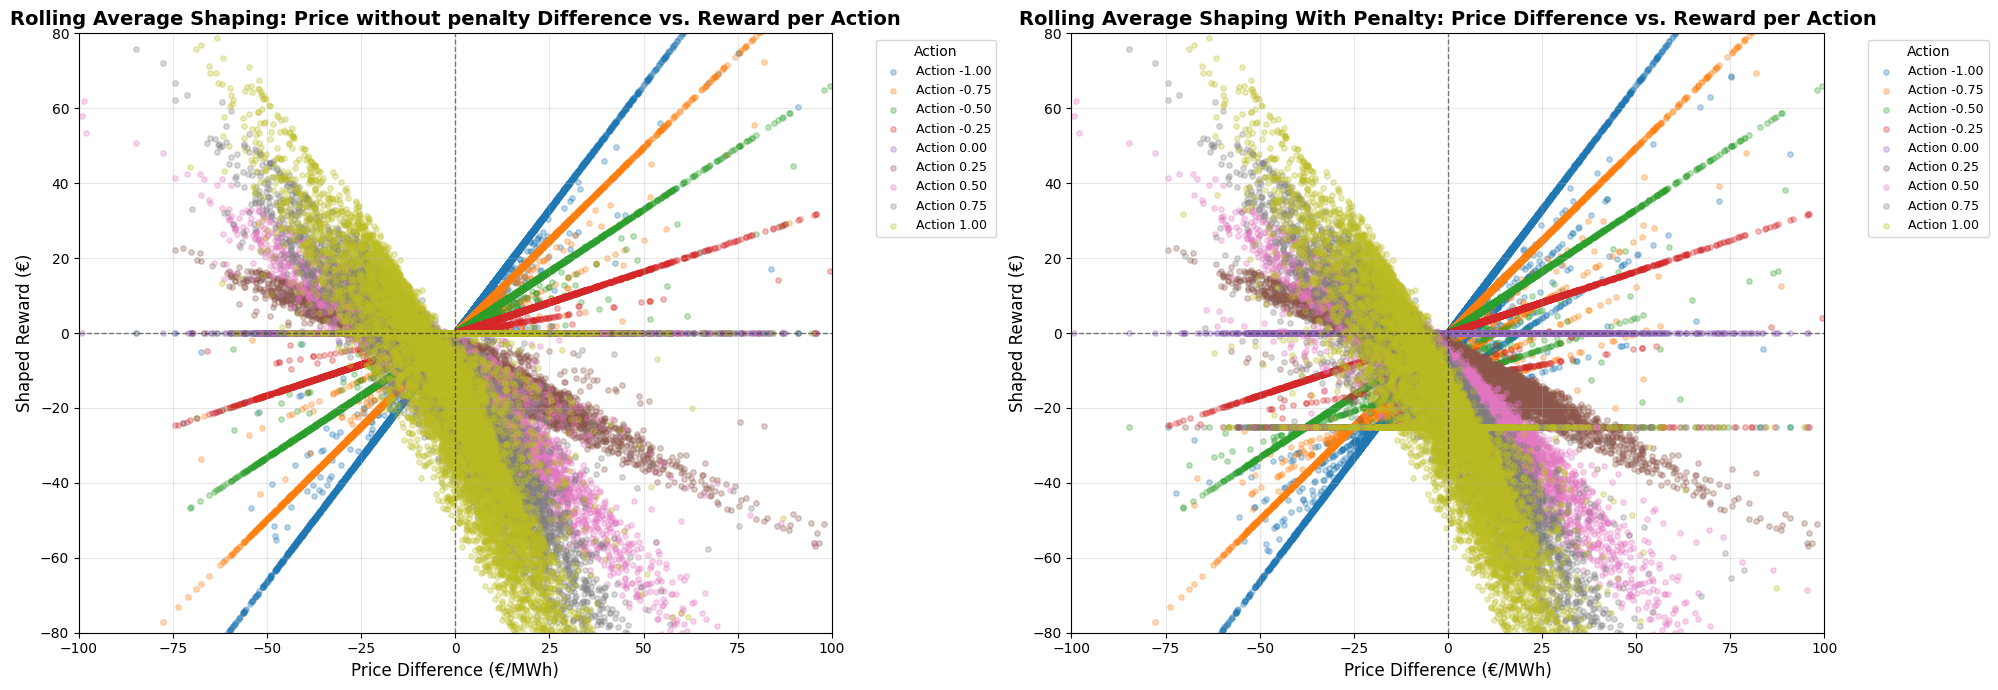

In [21]:
# Sample data
df_small = df.sample(100_000)

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Left plot: shaped_reward_constant
for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    df_group = df_temp.groupby('price_diff')['shaped_reward_rolling'].mean()
    ax1.scatter(df_group.index, df_group.values, label=f'Action {action:.2f}', s=15, alpha=0.3)

ax1.set_xlabel('Price Difference (€/MWh)', fontsize=12)
ax1.set_ylabel('Shaped Reward (€)', fontsize=12)
ax1.set_title('Rolling Average Shaping: Price without penalty Difference vs. Reward per Action', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action', fontsize=9)
ax1.set_xlim(-100, 100)
ax1.set_ylim(-80, 80)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Right plot: shaped_reward_rolling
for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    df_group = df_temp.groupby('price_diff')['shaped_penalty_reward'].mean()
    ax2.scatter(df_group.index, df_group.values, label=f'Action {action:.2f}', s=15, alpha=0.3)

ax2.set_xlabel('Price Difference (€/MWh)', fontsize=12)
ax2.set_ylabel('Shaped Reward (€)', fontsize=12)
ax2.set_title('Rolling Average Shaping With Penalty: Price Difference vs. Reward per Action', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action', fontsize=9)
ax2.set_xlim(-100, 100)
ax2.set_ylim(-80, 80)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()


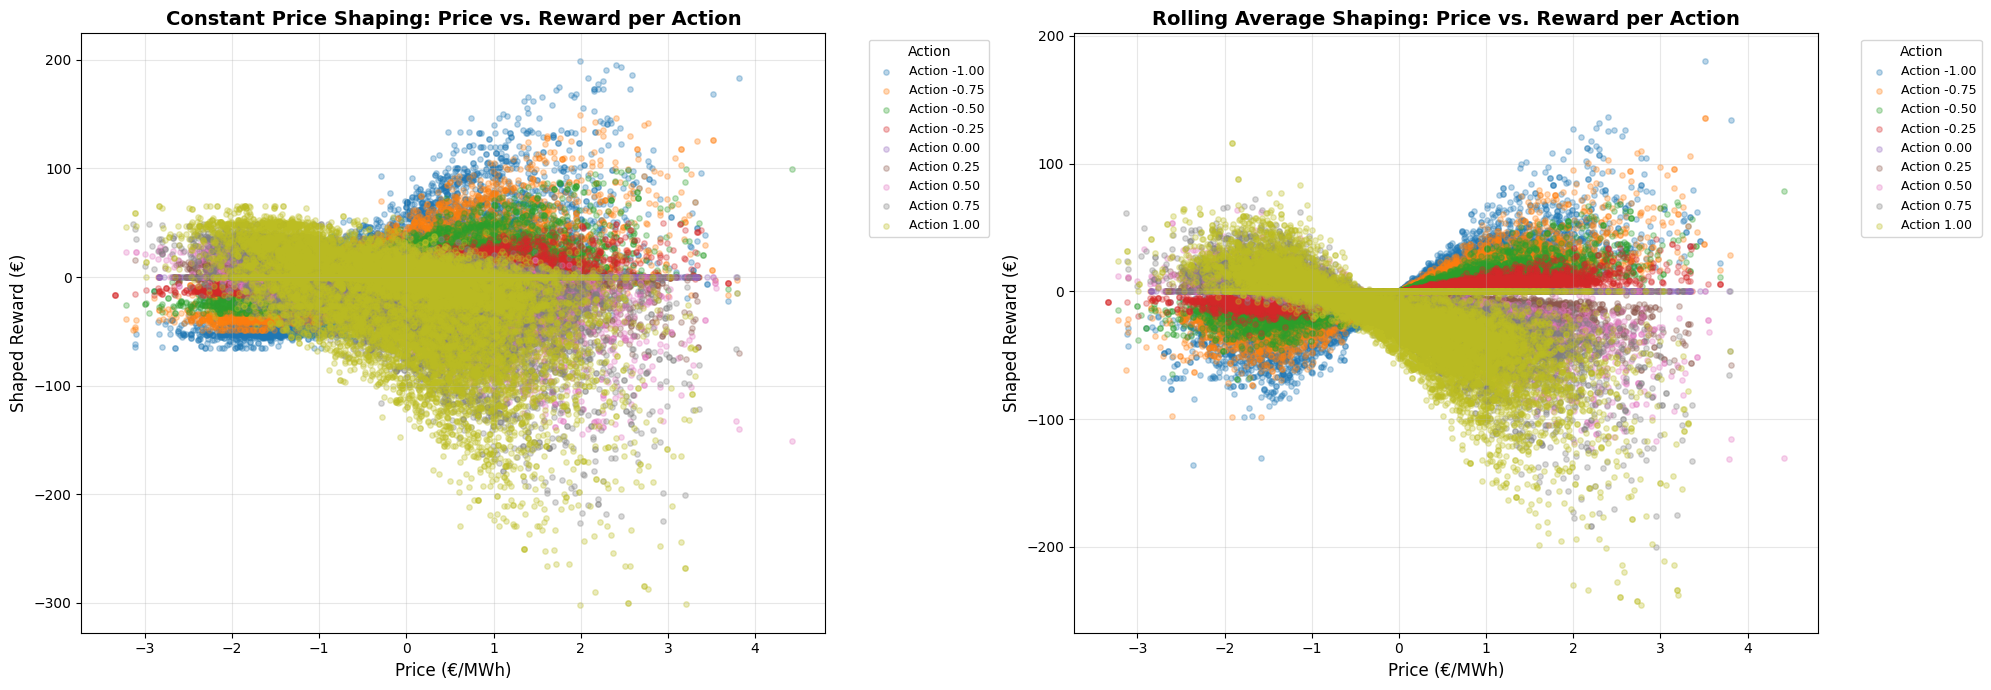

In [25]:
# Sample data
df_small = df.sample(100_000)

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Left plot: shaped_reward_constant
for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    df_group = df_temp.groupby('z_score')['shaped_reward_constant'].mean()
    ax1.scatter(df_group.index, df_group.values, label=f'Action {action:.2f}', s=15, alpha=0.3)

ax1.set_xlabel('Price (€/MWh)', fontsize=12)
ax1.set_ylabel('Shaped Reward (€)', fontsize=12)
ax1.set_title('Constant Price Shaping: Price vs. Reward per Action', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action', fontsize=9)
# ax1.set_xlim(0, 200)
# ax1.set_ylim(-80, 80)
ax1.grid(True, alpha=0.3)

for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    df_group = df_temp.groupby('z_score')['shaped_reward_rolling'].mean()
    ax2.scatter(df_group.index, df_group.values, label=f'Action {action:.2f}', s=15, alpha=0.3)

ax2.set_xlabel('Price (€/MWh)', fontsize=12)
ax2.set_ylabel('Shaped Reward (€)', fontsize=12)
ax2.set_title('Rolling Average Shaping: Price vs. Reward per Action', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action', fontsize=9)
# ax2.set_xlim(0, 200)
# ax2.set_ylim(-80, 80)
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()



In [29]:
n_bins_prices = 8
percentile = np.linspace(100/n_bins_prices, 100-100/n_bins_prices, n_bins_prices-1)
price_bins = np.percentile(df.z_score, percentile)
price_bins

array([-1.32303628, -0.78784834, -0.29405904,  0.06955585,  0.38411705,
        0.71288176,  1.16156112])

In [30]:
current_dir = os.path.dirname(os.path.abspath(__file__))
train_path = os.path.normpath(os.path.join(current_dir, '..', 'data\\train.xlsx'))
env = HydroElectric_Test(train_path)
train_prices = env.price_values.flatten()

percentile = np.linspace(100/n_bins_prices, 100-100/n_bins_prices, n_bins_prices-1)
price_bins = np.percentile(train_prices, percentile)



NameError: name '__file__' is not defined

In [27]:
df.z_score

0        -0.917490
1        -0.917490
2        -1.010347
3        -1.484990
4        -1.785347
            ...   
263025    1.120911
263026    0.776400
263027    0.182860
263028   -0.173648
263029    0.403884
Name: z_score, Length: 262270, dtype: float64

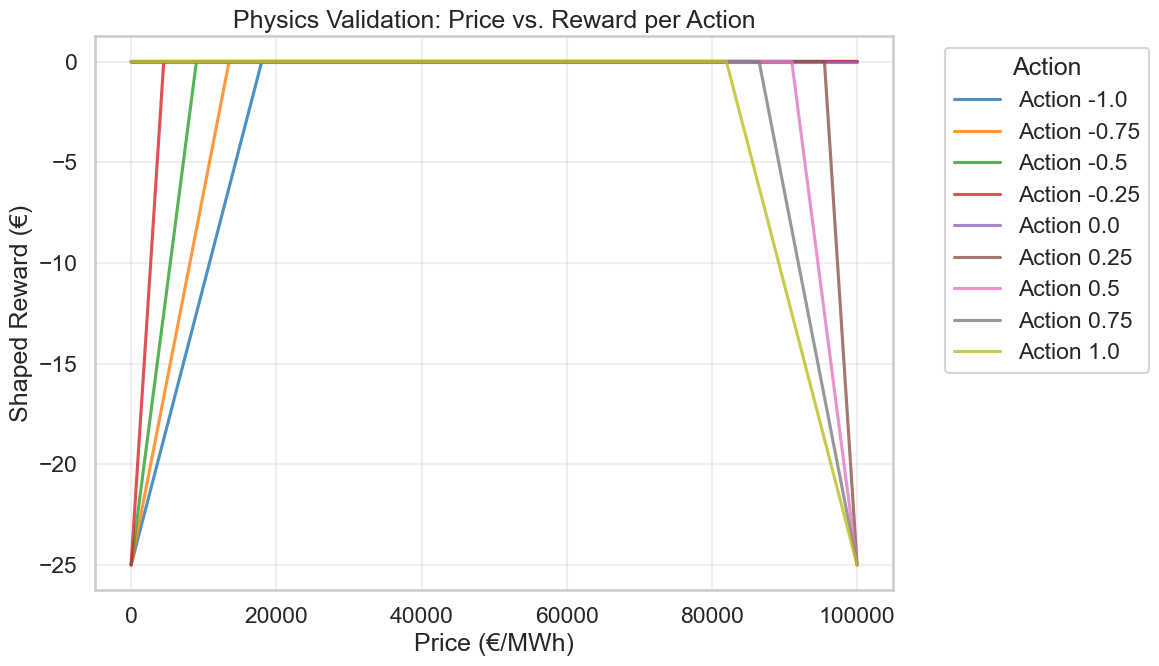

In [93]:
# plt.scatter(df.current_volume, df.penalty)
plt.figure(figsize=(12, 7))
start_day = (365*24)
n_days = 2*365

df_small = df
# Iterate through each action to plot them separately
for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    
    # Group by price and take the mean (as per your snippet)
    # Note: If prices are continuous floats, this effectively plots every point.
    df_group = df_temp.groupby('current_volume')['penalty'].mean()
    
    # Plot
    plt.plot(df_group.index, df_group.values, label=f'Action {action}', alpha=0.8)
    # plt.show()
plt.xlabel('Price (€/MWh)')
plt.ylabel('Shaped Reward (€)')
plt.title('Physics Validation: Price vs. Reward per Action')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action')
# plt.xlim(0,200)
# plt.ylim(-80, 80)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

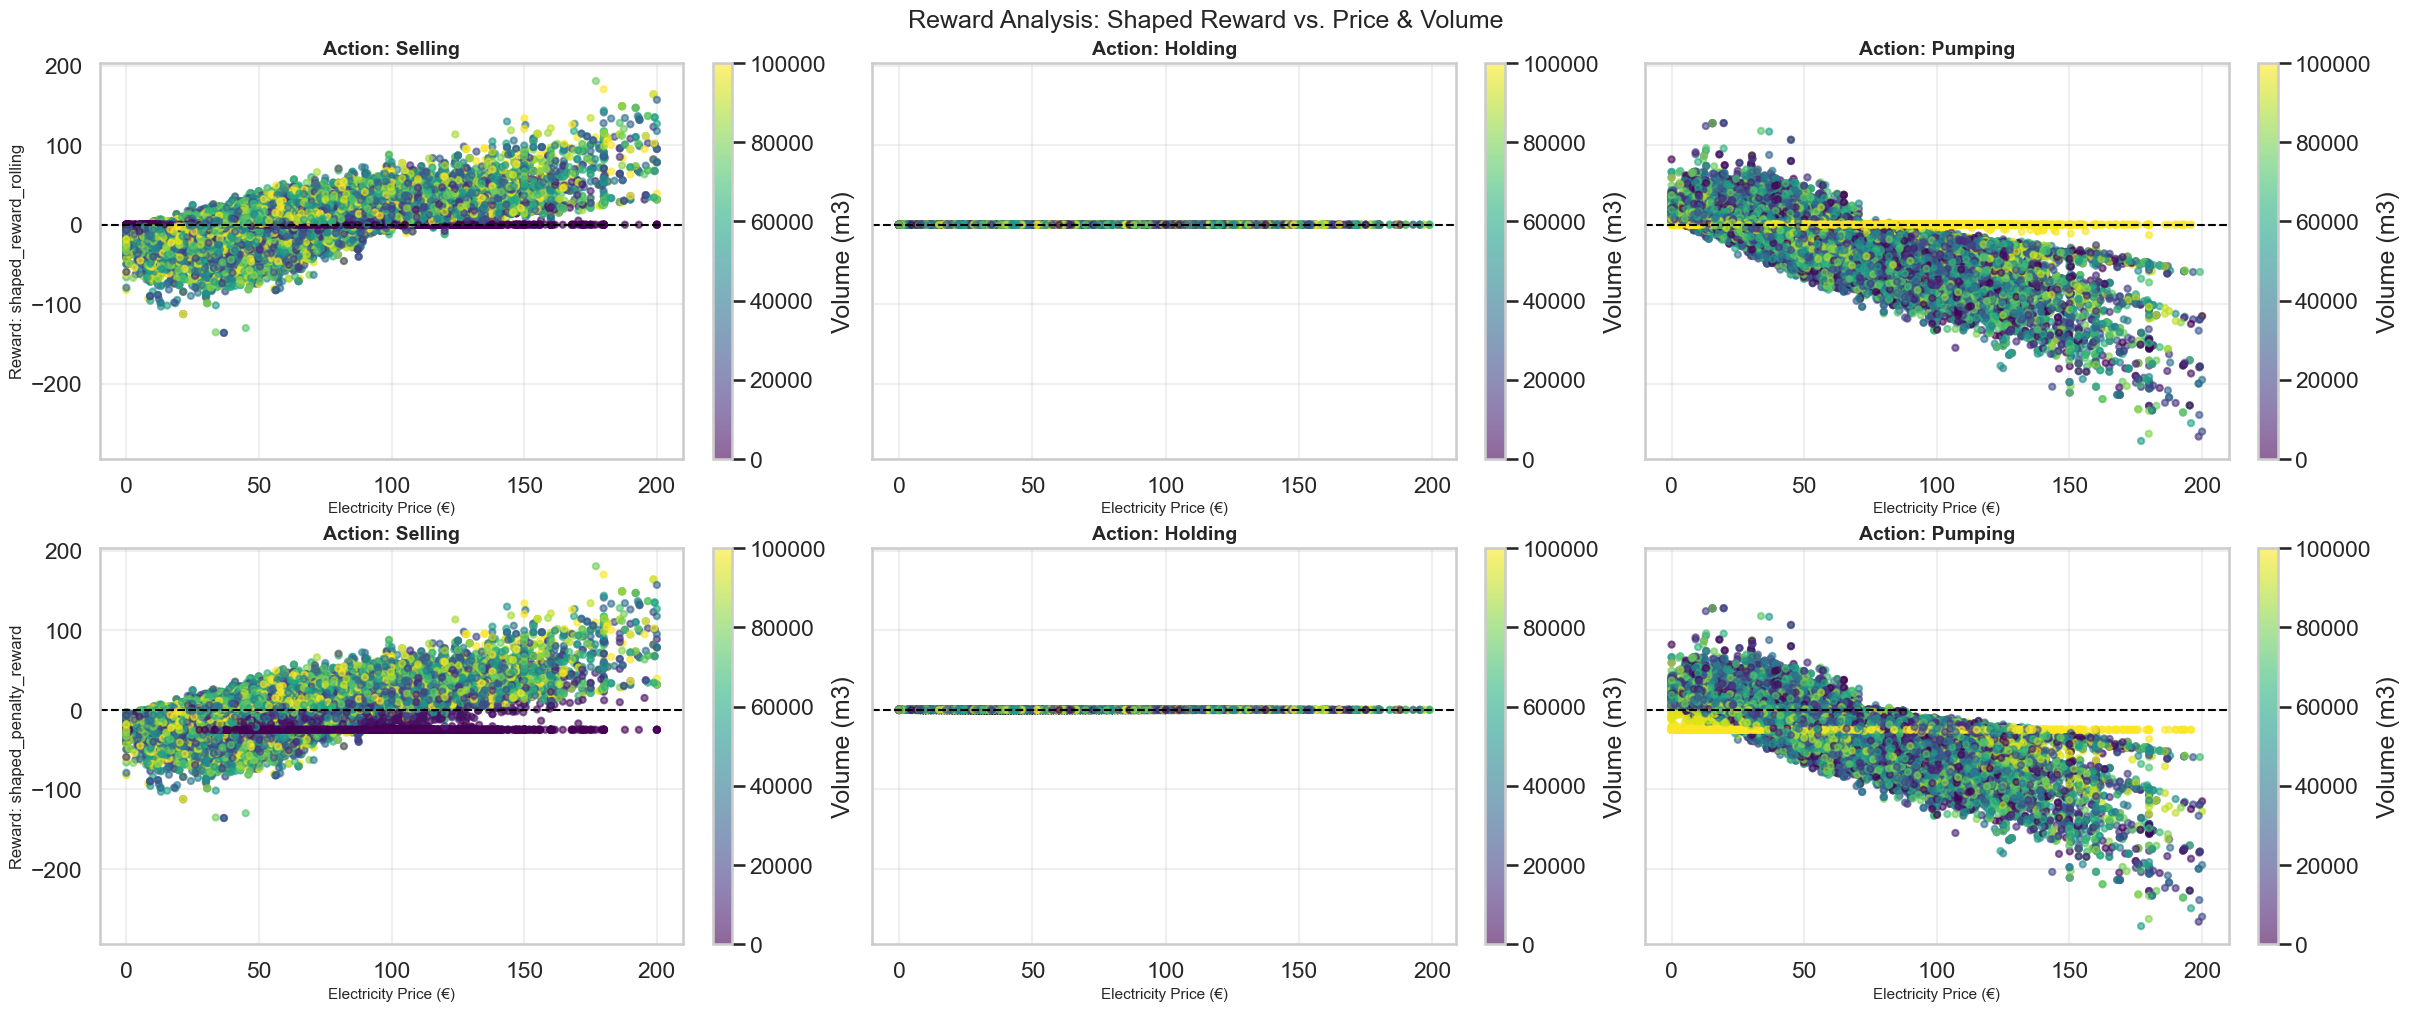

In [94]:
import matplotlib.pyplot as plt

reward_type = ['shaped_reward_rolling', 'shaped_penalty_reward']
action_type = ['Selling', 'Holding', 'Pumping']

# Create the subplots
# constrained_layout=True helps prevent overlapping labels automatically
fig, axes = plt.subplots(2, 3, figsize=(24, 10), sharey=True, constrained_layout=True)

for i, rt in enumerate(reward_type):
    for j, at in enumerate(action_type):
        
        # Select the specific axis based on row (i) and column (j)
        ax = axes[i, j]

        # Filter data based on Action Type
        if at == 'Selling':
            df_temp = df[df.action < 0]
        elif at == 'Pumping':
            df_temp = df[df.action > 0]
        else:
            df_temp = df[df.action == 0]

        # Scatter Plot
        # Dynamic label based on action type
        sc = ax.scatter(df_temp['price'], df_temp[rt], 
                        c=df_temp['current_volume'], cmap='viridis', 
                        s=20, alpha=0.6, label=at)
        
        # Dynamic Title
        ax.set_title(f"Action: {at}", fontsize=14, fontweight='bold')
        
        # Grid and Reference Line
        ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
        ax.grid(True, alpha=0.3)

        # --- Label Management ---
        # Only set Y-label for the first column to avoid clutter (since sharey=True)
        if j == 0:
            ax.set_ylabel(f"Reward: {rt}", fontsize=12)
        
        # Set X-label for all (or just bottom row if you prefer)
        ax.set_xlabel("Electricity Price (€)", fontsize=11)

        # --- Colorbar ---
        # Adding a colorbar to every plot can be messy. 
        # Here we add it to the current axis.
        cbar = fig.colorbar(sc, ax=ax)
        cbar.set_label('Volume (m3)')

# Set the main title outside the loop
plt.suptitle("Reward Analysis: Shaped Reward vs. Price & Volume", fontsize=18)

plt.show()

In [48]:
df.actual_flow*df.price*env.volume_to_MWh

0          8.943048
1         26.829145
2        -15.973145
3          9.292530
4         -0.014715
            ...    
263025    44.674776
263026    26.487021
263027     0.000000
263028   -27.391994
263029   -46.028557
Length: 262270, dtype: float64

In [52]:
4500*24.31*env.volume_to_MWh*1/0.8

11.17881050554125

In [54]:
9000*21.71*env.volume_to_MWh*0.9

14.3758307506554

,step,price,current_volume,next_volume,action,raw_reward,rolling_price,price_diff,shaped_reward_rolling,shaped_reward_constant,penalty,shaped_penalty_reward,intended_flow,actual_flow
0,1,24.31,50000.0,54500.0,0.25,-11.178811,50.000000,-25.690000,-14.673626,-14.639642,0.0,-14.673626,4500.0,4500.0
1,2,24.31,54500.0,68000.0,0.75,-33.536432,50.000000,-25.690000,-8.888787,-9.128463,0.0,-8.888787,13500.0,13500.0
2,3,21.71,68000.0,59000.0,-0.50,14.375831,50.000000,-28.290000,-40.437588,-39.904577,0.0,-40.437588,-9000.0,-9000.0
3,4,8.42,59000.0,72500.0,0.75,-11.615662,50.000000,-41.580000,11.376543,11.152965,0.0,11.376543,13500.0,13500.0
4,5,0.01,72500.0,54500.0,-1.00,0.013244,50.000000,-49.990000,-86.253513,-85.414647,0.0,-86.253513,-18000.0,-18000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263025,263026,40.48,14500.0,28000.0,0.75,-55.843470,27.387083,13.092917,-34.282903,-16.863579,0.0,-34.282903,13500.0,13500.0
263026,263027,36.00,28000.0,37000.0,0.50,-33.108776,27.137083,8.862917,-22.526730,-13.800980,0.0,-22.526730,9000.0,9000.0
263027,263028,29.00,37000.0,37000.0,0.00,0.000000,26.928333,2.071667,-7.330639,-13.479028,0.0,-7.330639,0.0,0.0
263028,263029,24.82,37000.0,23500.0,-0.75,24.652795,26.788333,-1.968333,-6.586813,-33.088444,0.0,-6.586813,-13500.0,-13500.0


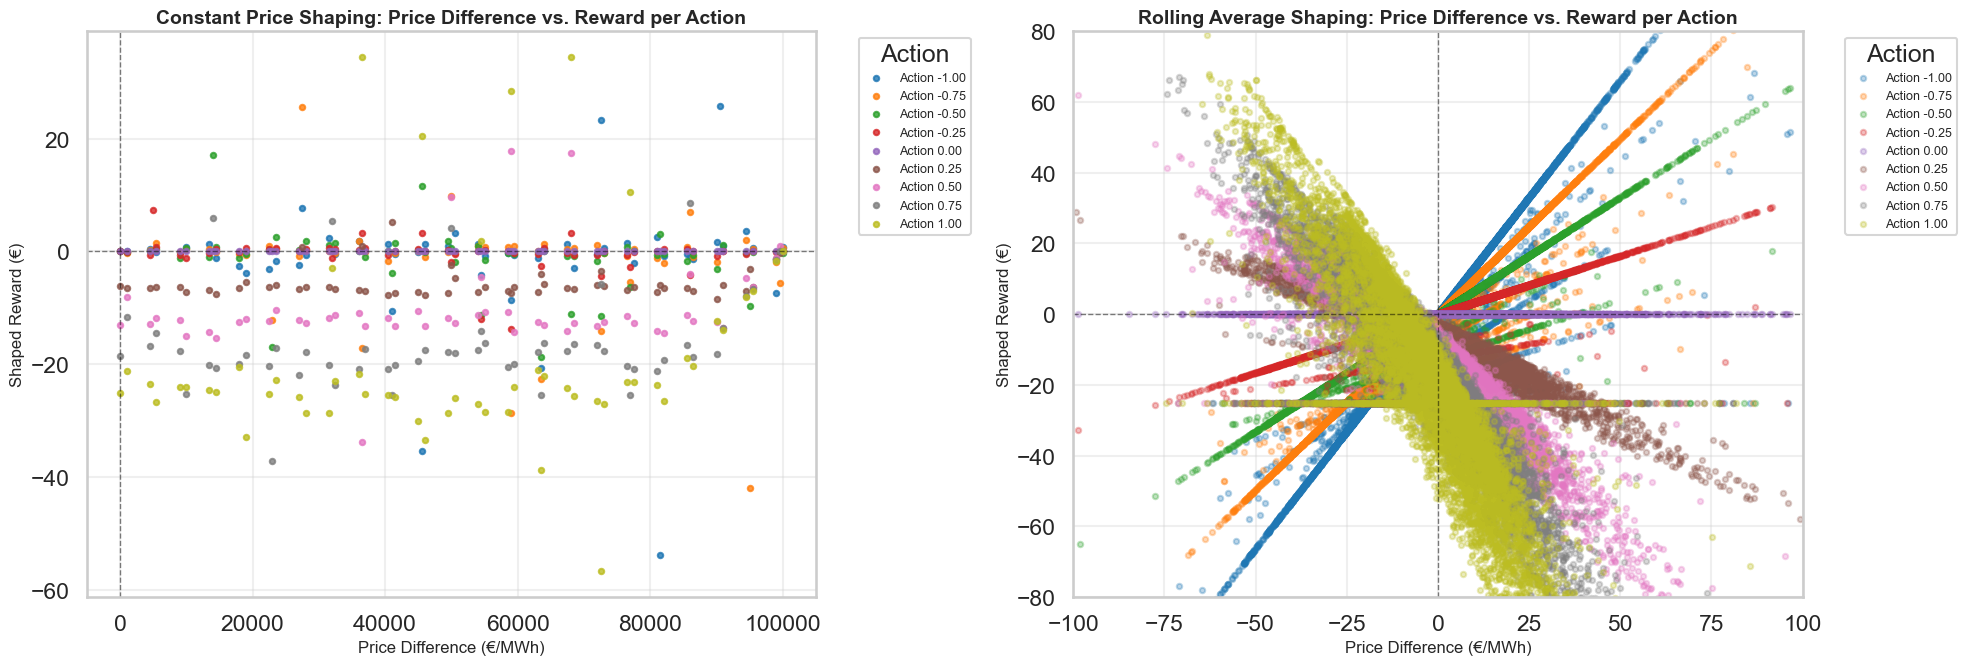

In [98]:
# Sample data
df_small = df.sample(100_000)

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Left plot: shaped_reward_constant
for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    df_group = df_temp.groupby('current_volume')['shaped_reward_rolling'].mean()
    ax1.scatter(df_group.index, df_group.values, label=f'Action {action:.2f}', s=15, alpha=0.8)

ax1.set_xlabel('Price Difference (€/MWh)', fontsize=12)
ax1.set_ylabel('Shaped Reward (€)', fontsize=12)
ax1.set_title('Constant Price Shaping: Price Difference vs. Reward per Action', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action', fontsize=9)
# ax1.set_xlim(-100, 100)
# ax1.set_ylim(-80, 80)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Right plot: shaped_reward_rolling
for action in sorted(df_small['action'].unique()):
    df_temp = df_small[df_small['action'] == action]
    df_group = df_temp.groupby('price_diff')['shaped_penalty_reward'].mean()
    ax2.scatter(df_group.index, df_group.values, label=f'Action {action:.2f}', s=15, alpha=0.3)

ax2.set_xlabel('Price Difference (€/MWh)', fontsize=12)
ax2.set_ylabel('Shaped Reward (€)', fontsize=12)
ax2.set_title('Rolling Average Shaping: Price Difference vs. Reward per Action', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Action', fontsize=9)
ax2.set_xlim(-100, 100)
ax2.set_ylim(-80, 80)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()


In [64]:
df

,step,price,current_volume,next_volume,action,raw_reward,rolling_price,price_diff,shaped_reward_rolling,shaped_reward_constant,penalty,shaped_penalty_reward,intended_flow,actual_flow
0,1,24.31,50000.0,54500.0,0.25,-11.178811,50.000000,-25.690000,3.370657,3.229177,0.0,3.370657,4500.0,4500.0
1,2,24.31,54500.0,68000.0,0.75,-33.536432,50.000000,-25.690000,13.625181,13.166577,0.0,13.625181,13500.0,13500.0
2,3,21.71,68000.0,59000.0,-0.50,14.375831,50.000000,-28.290000,-20.903410,-20.560351,0.0,-20.903410,-9000.0,-9000.0
3,4,8.42,59000.0,72500.0,0.75,-11.615662,50.000000,-41.580000,35.380406,34.923412,0.0,35.380406,13500.0,13500.0
4,5,0.01,72500.0,54500.0,-1.00,0.013244,50.000000,-49.990000,-68.209230,-67.545828,0.0,-68.209230,-18000.0,-18000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263025,263026,40.48,14500.0,28000.0,0.75,-55.843470,27.387083,13.092917,-29.205087,-7.683269,0.0,-29.205087,13500.0,13500.0
263026,263027,36.00,28000.0,37000.0,0.50,-33.108776,27.137083,8.862917,-15.878011,-1.669856,0.0,-15.878011,9000.0,9000.0
263027,263028,29.00,37000.0,37000.0,0.00,0.000000,26.928333,2.071667,-0.733064,-1.347903,0.0,-0.733064,0.0,0.0
263028,263029,24.82,37000.0,23500.0,-0.75,24.652795,26.788333,-1.968333,-2.418247,-25.383541,0.0,-2.418247,-13500.0,-13500.0


C:\Users\sonne\AppData\Local\Temp\ipykernel_23800\2917320020.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  policy_matrix = df.groupby(['vol_bin', 'price_bin'], observed=False).apply(get_consensus_action).unstack()


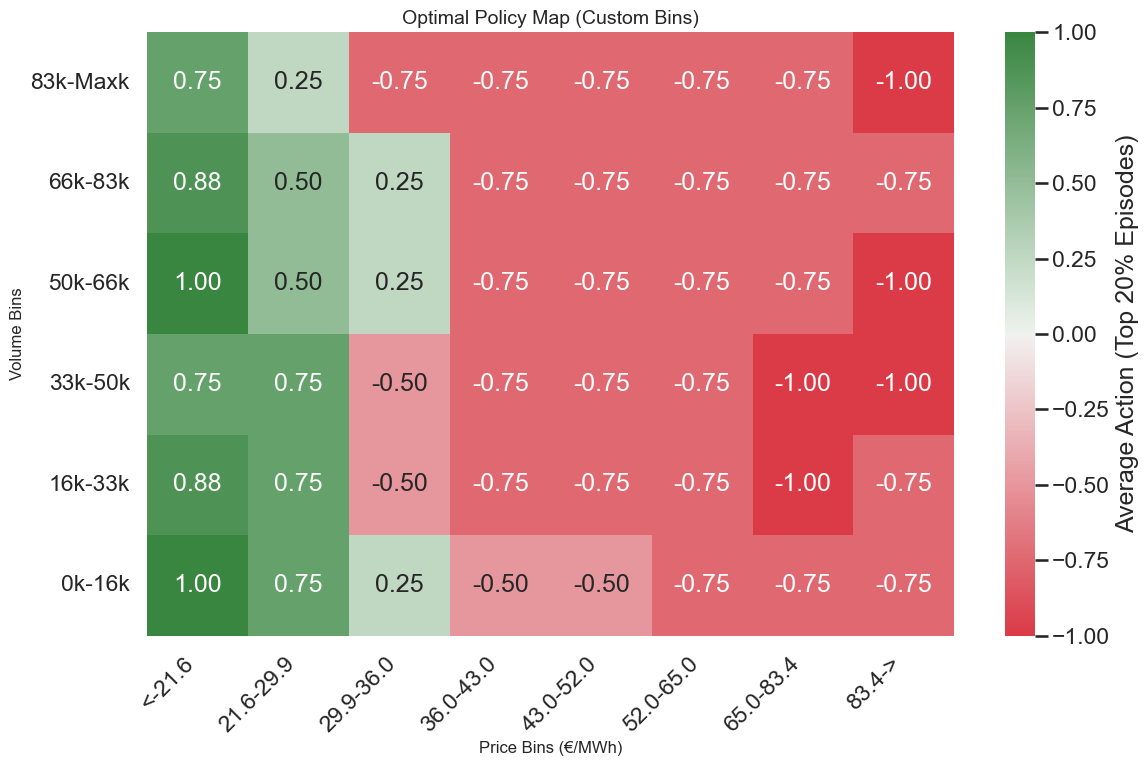

In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define Custom Bins ---
# I added -np.inf and np.inf to the ends to ensure NO data is lost.
# If you strictly want only the ranges you provided, remove the infs.

# Volume: 0 -> 16k -> ... -> 83k -> Max
custom_vol_bins = [0, 16666.67, 33333.33, 50000.0, 66666.67, 83333.33, np.inf]

# Price: Min -> 21.62 -> ... -> 83.39 -> Max
custom_price_bins = [-np.inf, 21.62, 29.9, 36.0, 43.0, 52.0, 65.0, 83.39, np.inf]

# Apply the custom bins
df['vol_bin'] = pd.cut(df['current_volume'], bins=custom_vol_bins)
df['price_bin'] = pd.cut(df['price'], bins=custom_price_bins)

# --- 2. Calculate Consensus Action (Top 20% Logic) ---
def get_consensus_action(group, quantile=0.9, min_samples=5):
    if len(group) < min_samples:
        return np.nan
    threshold = group['shaped_reward_rolling'].quantile(quantile)
    top_performers = group[group['shaped_reward_rolling'] >= threshold]
    return top_performers['action'].median()

# Calculate the heatmap matrix
policy_matrix = df.groupby(['vol_bin', 'price_bin'], observed=False).apply(get_consensus_action).unstack()

# Sort so High Volume is at the top
policy_matrix = policy_matrix.sort_index(ascending=False)

# --- 3. Plotting ---
plt.figure(figsize=(12, 8))

# Diverging Colormap (Red=Sell, Gray=Hold, Green=Pump)
cmap = sns.diverging_palette(10, 130, as_cmap=True)

ax = sns.heatmap(policy_matrix, cmap=cmap, center=0, annot=True, fmt=".2f",
                 cbar_kws={'label': 'Average Action (Top 20% Episodes)'})

# --- Custom Label Formatting ---
# Since bins are non-uniform, we label them by their interval range
# x_labels (Price)
x_labels = []
for interval in policy_matrix.columns:
    # Use 'inf' symbol or actual numbers
    left = f"{interval.left:.1f}" if interval.left != -np.inf else "<"
    right = f"{interval.right:.1f}" if interval.right != np.inf else ">"
    x_labels.append(f"{left}-{right}")

# y_labels (Volume) - Convert to 'k' (thousands)
y_labels = []
for interval in policy_matrix.index:
    left = int(interval.left / 1000)
    right = "Max" if interval.right == np.inf else int(interval.right / 1000)
    y_labels.append(f"{left}k-{right}k")

ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_yticklabels(y_labels, rotation=0)

plt.title("Optimal Policy Map (Custom Bins)", fontsize=14)
plt.xlabel("Price Bins (€/MWh)", fontsize=12)
plt.ylabel("Volume Bins", fontsize=12)
plt.tight_layout()
plt.show()

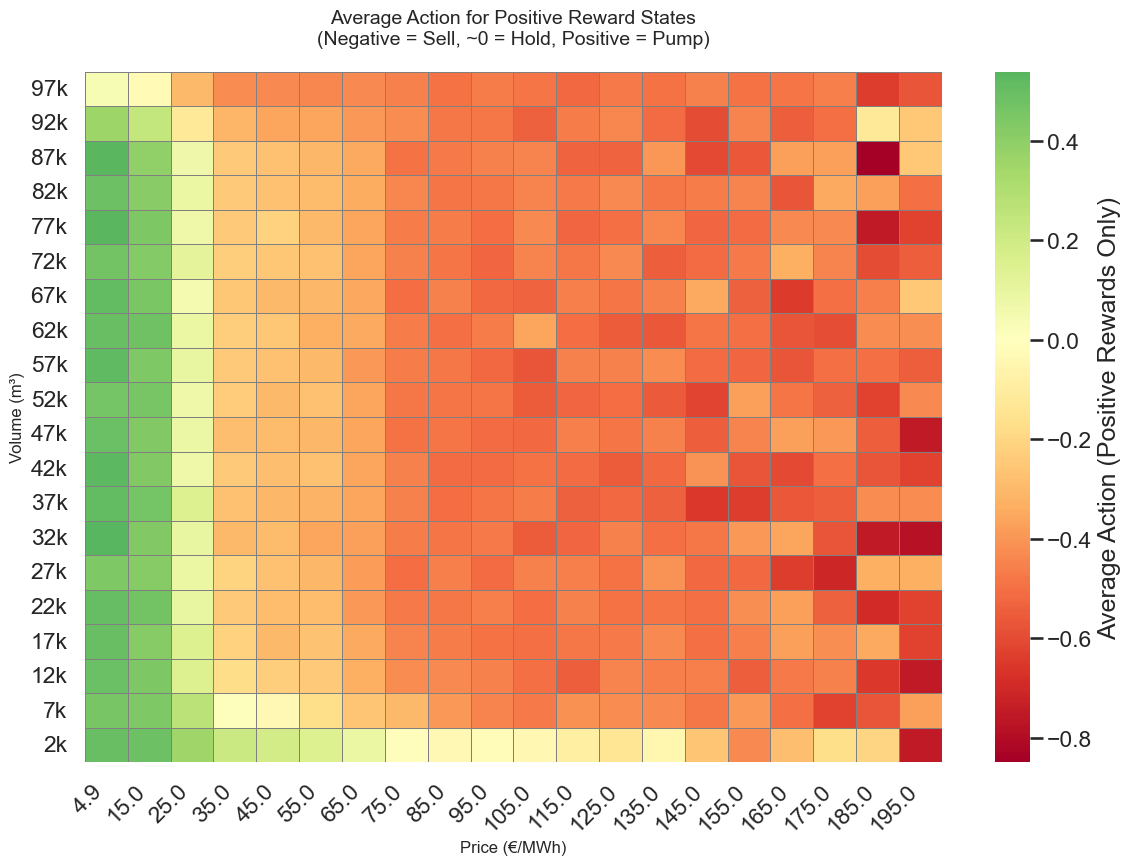


=== Summary Statistics ===
Total data points: 262270
Positive reward points: 105845 (40.4%)

Action range in positive rewards:
  Min: -1.000
  Max: 1.000
  Mean: -0.177
  Median: -0.250

Bins with positive reward data: 400/400 (100.0%)


In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter data
df = df[df.price < 200]

# Create bins for state space
n_bins = 20
df['vol_bin'] = pd.cut(df['current_volume'], bins=n_bins)
df['price_bin'] = pd.cut(df['price'], bins=n_bins)

# Filter for positive rewards only
df_positive = df[df['shaped_penalty_reward'] >= 0].copy()

# Calculate mean action for each state bin (only positive rewards)
policy_stats = df_positive.groupby(['vol_bin', 'price_bin'], observed=False)['action'].mean().reset_index()

# Create pivot table for heatmap
policy_matrix = policy_stats.pivot(index='vol_bin', columns='price_bin', values='action')
policy_matrix = policy_matrix.sort_index(ascending=False)  # High volume at top

# Create the plot
plt.figure(figsize=(12, 9))

# Use a diverging colormap centered at 0 (Hold action)
# Negative = Sell (red), 0 = Hold (white), Positive = Pump (green)
ax = sns.heatmap(policy_matrix, 
                 cmap='RdYlGn',  # Red-Yellow-Green diverging colormap
                 center=0,  # Center colorbar at 0 (Hold)
                 annot=False, 
                 fmt=".2f",  # Show action values with 2 decimals
                 cbar_kws={'label': 'Average Action (Positive Rewards Only)'},
                 linewidths=0.5,
                 linecolor='gray',
                 )

# Clean up axis labels
x_labels = [f"{i.mid:.1f}" for i in policy_matrix.columns]
y_labels = [f"{int(i.mid/1000)}k" for i in policy_matrix.index]
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_yticklabels(y_labels, rotation=0)

plt.title("Average Action for Positive Reward States\n(Negative = Sell, ~0 = Hold, Positive = Pump)", 
          fontsize=14, pad=20)
plt.xlabel("Price (€/MWh)", fontsize=12)
plt.ylabel("Volume (m³)", fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Print summary statistics
print("\n=== Summary Statistics ===")
print(f"Total data points: {len(df)}")
print(f"Positive reward points: {len(df_positive)} ({100*len(df_positive)/len(df):.1f}%)")
print(f"\nAction range in positive rewards:")
print(f"  Min: {df_positive['action'].min():.3f}")
print(f"  Max: {df_positive['action'].max():.3f}")
print(f"  Mean: {df_positive['action'].mean():.3f}")
print(f"  Median: {df_positive['action'].median():.3f}")

# Count bins with data
non_empty_bins = policy_matrix.notna().sum().sum()
total_bins = policy_matrix.shape[0] * policy_matrix.shape[1]
print(f"\nBins with positive reward data: {non_empty_bins}/{total_bins} ({100*non_empty_bins/total_bins:.1f}%)")

In [35]:
df

,step,price,volume,action,raw_reward,shaped_reward,cumulative_raw,cumulative_shaped,action_type,vol_bin,price_bin
0,1,24.31,50000.000000,-0.307782,9.909045,-26.827253,9.909045e+00,-2.682725e+01,Sell,"(45000.0, 50000.0]","(20.008, 30.007]"
1,2,24.31,44459.917969,0.849706,-37.994808,-3.711609,-2.808576e+01,-3.053886e+01,Pump,"(40000.0, 45000.0]","(20.008, 30.007]"
2,3,21.71,59754.625000,0.253375,-10.117979,-17.000157,-3.820374e+01,-4.753902e+01,Pump,"(55000.0, 60000.0]","(20.008, 30.007]"
3,4,8.42,64315.371094,0.962127,-14.900983,18.777678,-5.310472e+01,-2.876134e+01,Pump,"(60000.0, 65000.0]","(-0.19, 10.009]"
4,5,0.01,81633.648438,-0.534799,0.007083,-61.895670,-5.309764e+01,-9.065701e+01,Sell,"(80000.0, 85000.0]","(-0.19, 10.009]"
...,...,...,...,...,...,...,...,...,...,...,...
263025,263026,40.48,17897.353516,0.452720,-33.708640,-13.312402,-1.500273e+06,-6.337560e+06,Pump,"(15000.0, 20000.0]","(40.006, 50.005]"
263026,263027,36.00,26046.320312,0.453910,-30.056836,-12.587483,-1.500303e+06,-6.337573e+06,Pump,"(25000.0, 30000.0]","(30.007, 40.006]"
263027,263028,29.00,34216.707031,-0.276292,10.611318,-18.442005,-1.500292e+06,-6.337591e+06,Sell,"(30000.0, 35000.0]","(20.008, 30.007]"
263028,263029,24.82,29243.451172,-0.302829,9.954122,-18.851183,-1.500282e+06,-6.337610e+06,Sell,"(25000.0, 30000.0]","(20.008, 30.007]"


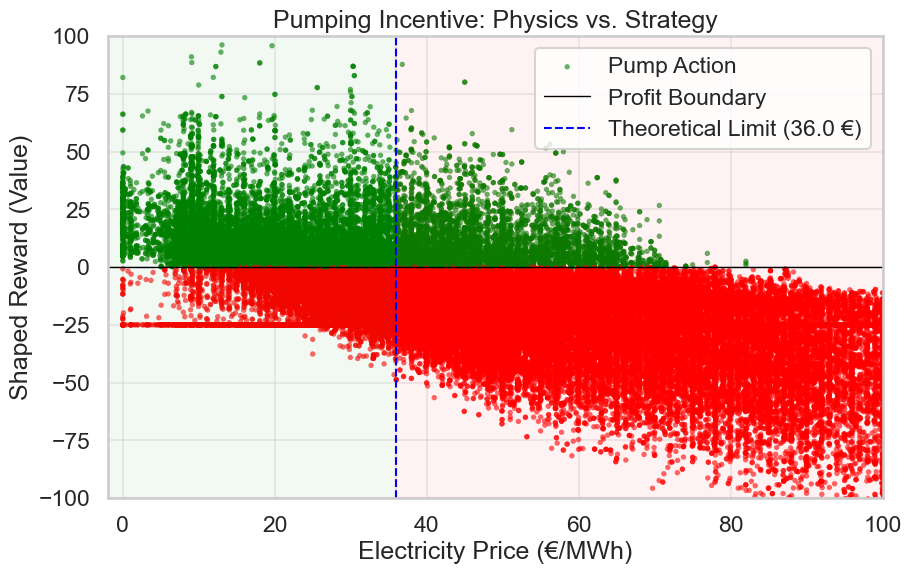

In [110]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data (Assuming 'df' comes from the previous simulation)
# Filter for PUMP actions only (Action > 0)
df_pump = df[df['action'] > 0].copy()

# 2. Define Thresholds
AVG_PRICE = 50
THEORETICAL_THRESHOLD = AVG_PRICE * 0.72  # ~36.0 EUR

# 3. Create Color Logic
# Green if Shaping says "Yes! Do it!" (Reward > 0)
# Red if Shaping says "Stop! Too expensive!" (Reward <= 0)
colors = np.where(df_pump['shaped_penalty_reward'] > 0, 'green', 'red')

# 4. Plot
plt.figure(figsize=(10, 6))

# Scatter plot with dynamic colors
plt.scatter(df_pump['price'], df_pump['shaped_penalty_reward'], 
            c=colors, s=15, alpha=0.6, edgecolors='none', label='Pump Action')

# 5. Add Insight Lines
# Horizontal Zero Line (The Profit/Loss boundary)
plt.axhline(0, color='black', linewidth=1, linestyle='-', label='Profit Boundary')

# Vertical Threshold Line (The "Math" boundary: 36 EUR)
plt.axvline(THEORETICAL_THRESHOLD, color='blue', linestyle='--', linewidth=1.5, 
            label=f'Theoretical Limit ({THEORETICAL_THRESHOLD:.1f} €)')

# 6. Add "Zones" for clarity
plt.axvspan(-2, THEORETICAL_THRESHOLD, color='green', alpha=0.05) # Good Zone
plt.axvspan(THEORETICAL_THRESHOLD, 200, color='red', alpha=0.05)   # Bad Zone

# Formatting
plt.xlim(-2, 100) # Zoomed in on relevant prices
plt.ylim(-100, 100)
plt.xlabel('Electricity Price (€/MWh)')
plt.ylabel('Shaped Reward (Value)')
plt.title('Pumping Incentive: Physics vs. Strategy')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.show()

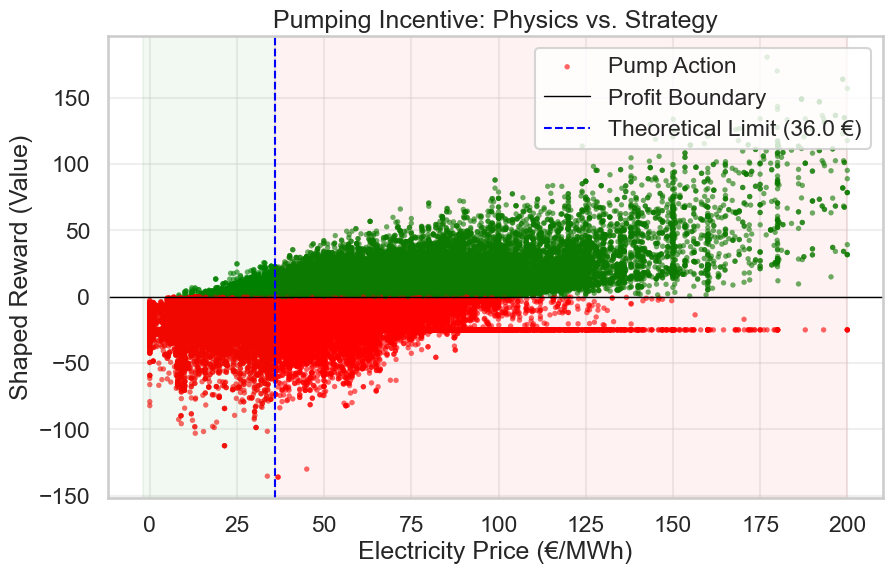

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data (Assuming 'df' comes from the previous simulation)
# Filter for PUMP actions only (Action > 0)
df_pump = df[df['action'] < 0].copy()

# 2. Define Thresholds
AVG_PRICE = 50
THEORETICAL_THRESHOLD = AVG_PRICE * 0.72  # ~36.0 EUR

# 3. Create Color Logic
# Green if Shaping says "Yes! Do it!" (Reward > 0)
# Red if Shaping says "Stop! Too expensive!" (Reward <= 0)
colors = np.where(df_pump['shaped_penalty_reward'] > 0, 'green', 'red')

# 4. Plot
plt.figure(figsize=(10, 6))

# Scatter plot with dynamic colors
plt.scatter(df_pump['price'], df_pump['shaped_penalty_reward'], 
            c=colors, s=15, alpha=0.6, edgecolors='none', label='Pump Action')

# 5. Add Insight Lines
# Horizontal Zero Line (The Profit/Loss boundary)
plt.axhline(0, color='black', linewidth=1, linestyle='-', label='Profit Boundary')

# Vertical Threshold Line (The "Math" boundary: 36 EUR)
plt.axvline(THEORETICAL_THRESHOLD, color='blue', linestyle='--', linewidth=1.5, 
            label=f'Theoretical Limit ({THEORETICAL_THRESHOLD:.1f} €)')

# 6. Add "Zones" for clarity
plt.axvspan(-2, THEORETICAL_THRESHOLD, color='green', alpha=0.05) # Good Zone
plt.axvspan(THEORETICAL_THRESHOLD, 200, color='red', alpha=0.05)   # Bad Zone

# Formatting
# plt.xlim(-2, 100) # Zoomed in on relevant prices
# plt.ylim(-100, 100)
plt.xlabel('Electricity Price (€/MWh)')
plt.ylabel('Shaped Reward (Value)')
plt.title('Pumping Incentive: Physics vs. Strategy')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

plt.show()

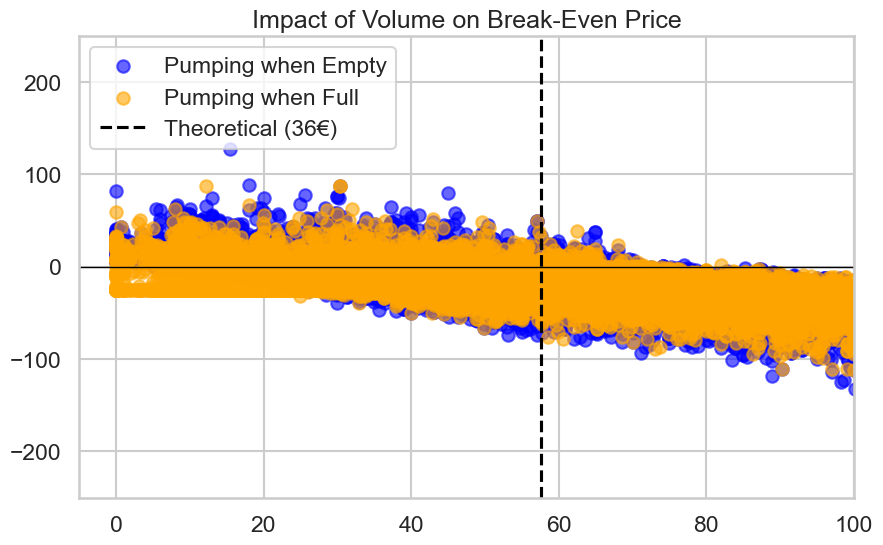

In [113]:
# Filter data
df_empty = df[(df['action'] > 0) & (df['current_volume'] < 10000)] # Near Empty
df_full  = df[(df['action'] > 0) & (df['current_volume'] > 80000)] # Near Full

plt.figure(figsize=(10, 6))

# Plot Empty Tank Pumping (Should be close to 36)
plt.scatter(df_empty['price'], df_empty['shaped_penalty_reward'], 
            color='blue', label='Pumping when Empty', alpha=0.6)

# Plot Full Tank Pumping (Should be shifted Left/Down)
plt.scatter(df_full['price'], df_full['shaped_penalty_reward'], 
            color='orange', label='Pumping when Full', alpha=0.6)

plt.axvline(80*0.72, color='black', linestyle='--', label='Theoretical (36€)')
plt.axhline(0, color='black', linewidth=1)
plt.xlim(-5, 100)
plt.ylim(-250, 250)
plt.legend()
plt.title("Impact of Volume on Break-Even Price")
plt.grid(True)
plt.show()

In [124]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_reward_heatmap(
    df,
    reward_col,
    title,
    price_bins=40,
    volume_bins=40,
    price_range=(0, 100),
    volume_range=(0, 100_000),
):
    df = df.copy()

    # Equal-width bins
    df["price_bin"] = pd.cut(
        df["price"],
        bins=np.linspace(*price_range, price_bins + 1),
        include_lowest=True,
    )

    df["volume_bin"] = pd.cut(
        df["current_volume"],
        bins=np.linspace(*volume_range, volume_bins + 1),
        include_lowest=True,
    )

    # Pivot table: mean reward
    pivot = (
        df.pivot_table(
            index="price_bin",
            columns="volume_bin",
            values=reward_col,
            aggfunc="mean",
        )
        .sort_index(ascending=True)
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        pivot,
        cmap="coolwarm",
        center=0,
        cbar_kws={"label": reward_col},
    )
    plt.title(title)
    plt.xlabel("Volume bin")
    plt.ylabel("Price bin")
    plt.tight_layout()
    plt.show()

ACTION_BINS = {
    "Sell": df.action <= -0.05,
    "Hold": df.action.abs() <= 0.05,
    "Pump": df.action >= 0.05,
}



C:\Users\sonne\AppData\Local\Temp\ipykernel_23800\2384081442.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


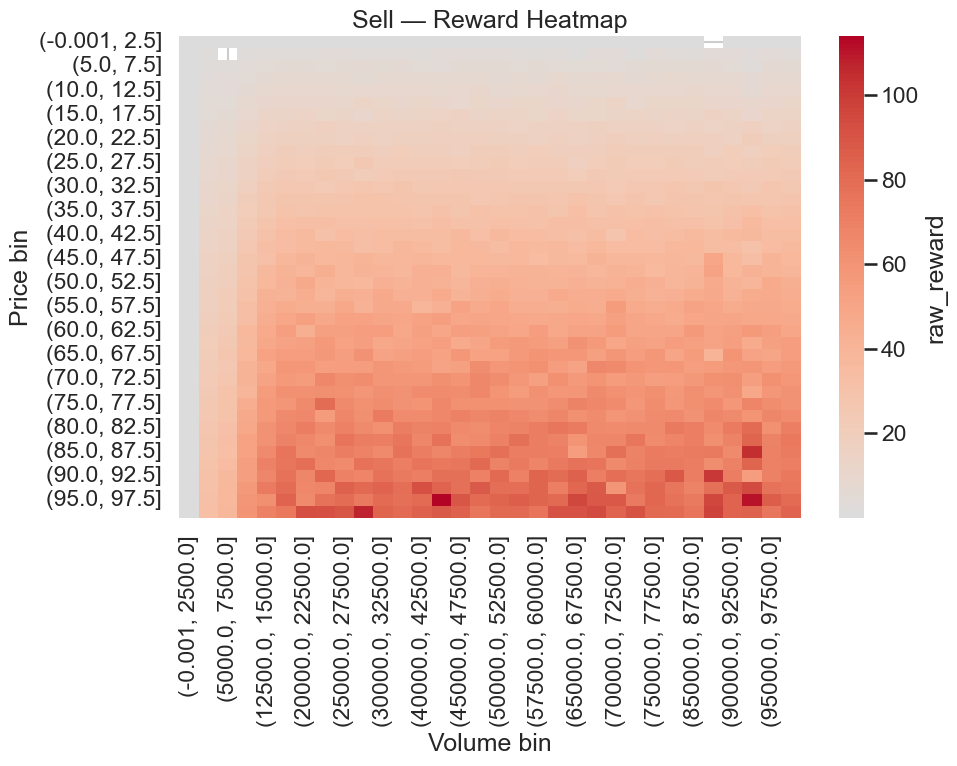

C:\Users\sonne\AppData\Local\Temp\ipykernel_23800\2384081442.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


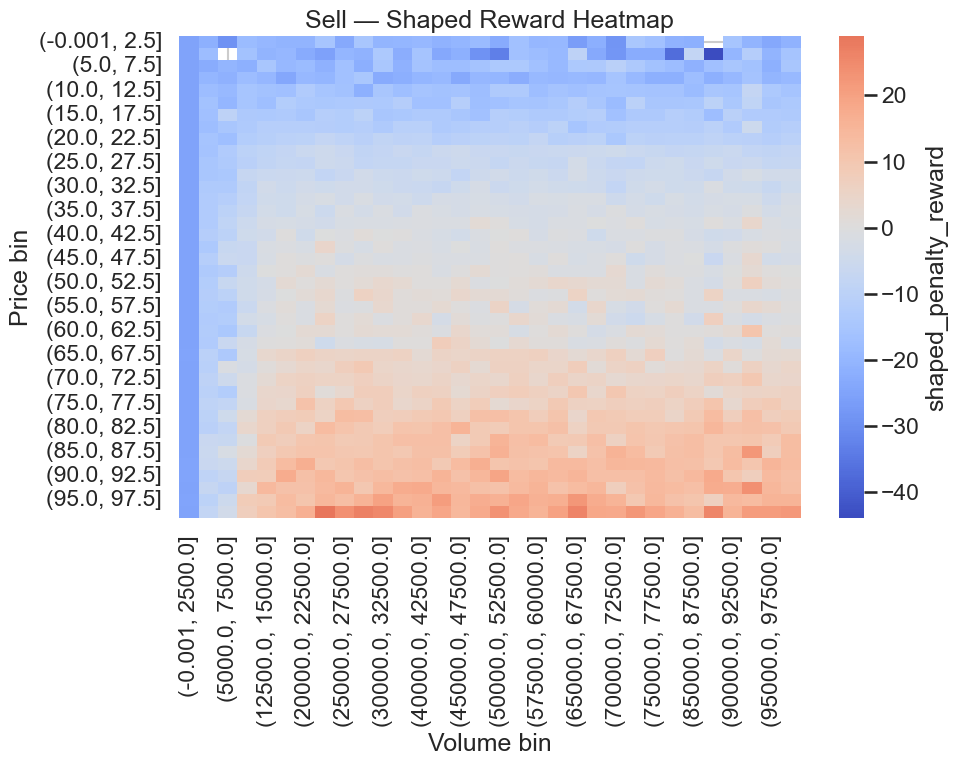

C:\Users\sonne\AppData\Local\Temp\ipykernel_23800\2384081442.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


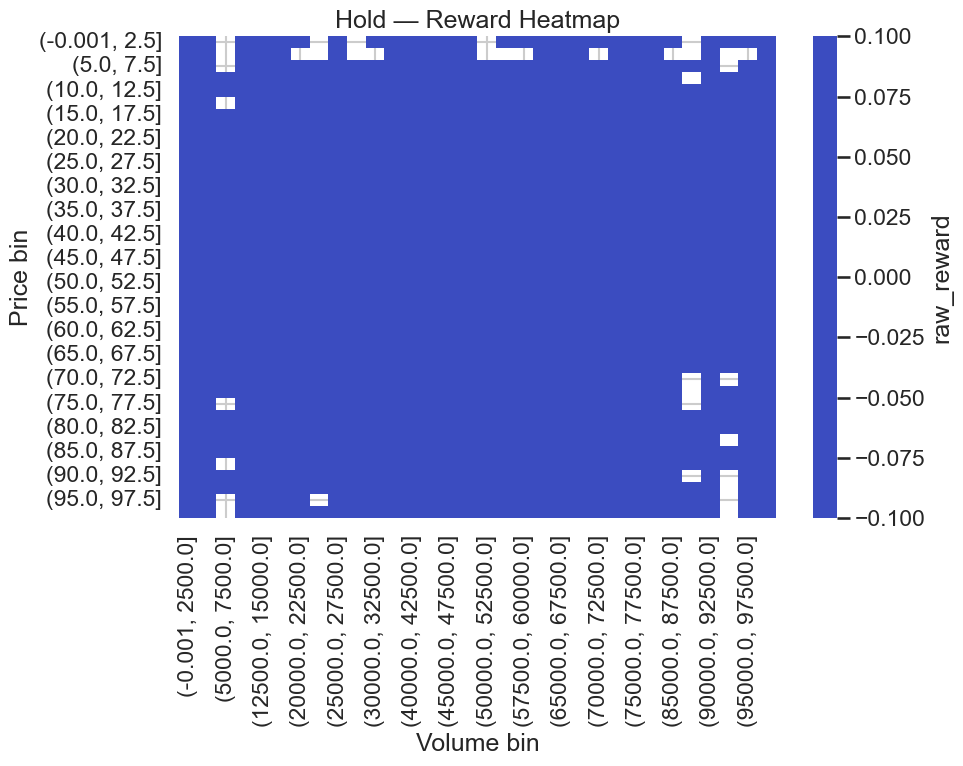

C:\Users\sonne\AppData\Local\Temp\ipykernel_23800\2384081442.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


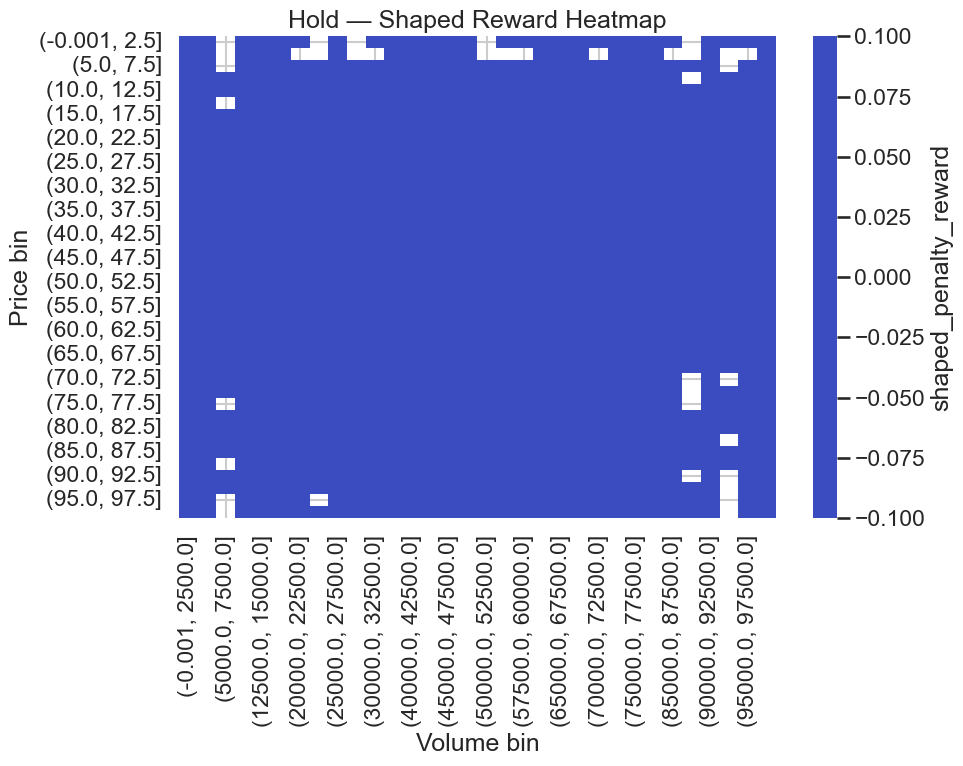

C:\Users\sonne\AppData\Local\Temp\ipykernel_23800\2384081442.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


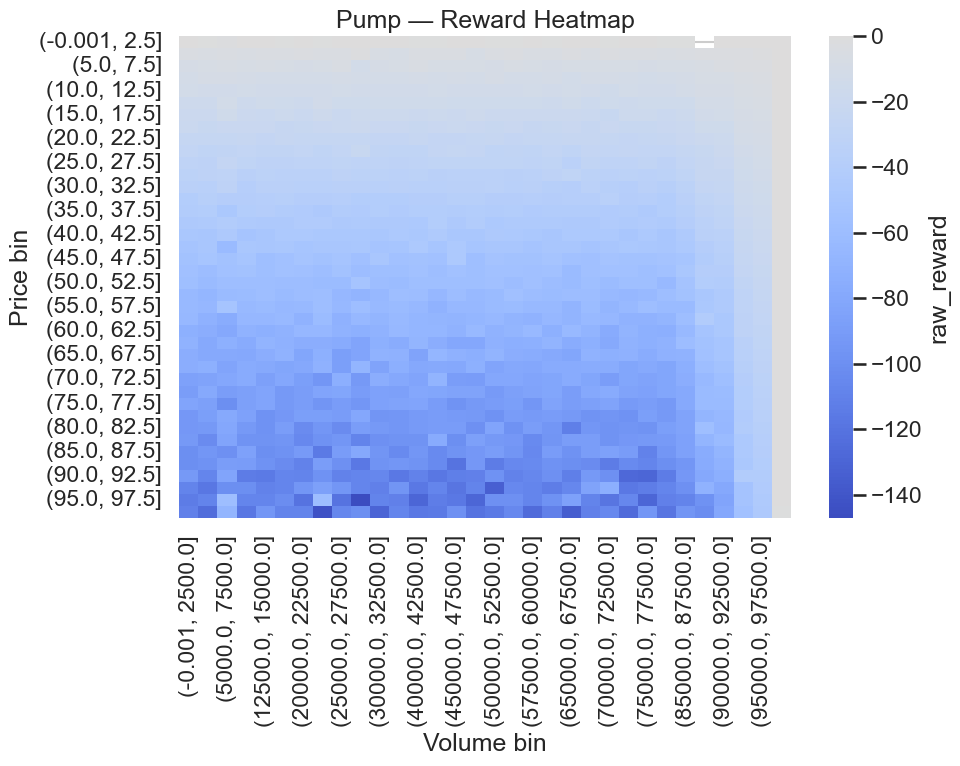

C:\Users\sonne\AppData\Local\Temp\ipykernel_23800\2384081442.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


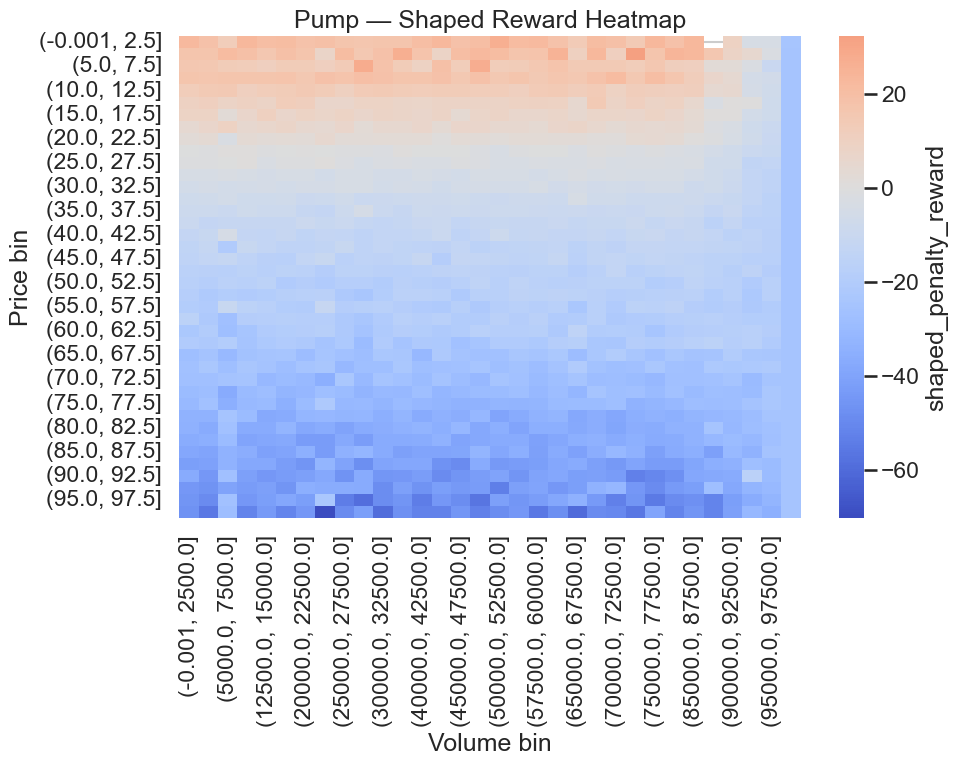

In [126]:
for action_name, mask in ACTION_BINS.items():
    df_action = df.loc[mask]

    if df_action.empty:
        continue

    # Raw reward
    plot_reward_heatmap(
        df_action,
        reward_col="raw_reward",
        title=f"{action_name} — Reward Heatmap",
    )

    # Shaped reward
    plot_reward_heatmap(
        df_action,
        reward_col="shaped_penalty_reward",
        title=f"{action_name} — Shaped Reward Heatmap",
    )
